# The Kullback–Leibler divergence

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/distances/kl.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

The **Kullback–Leibler (KL) divergence** of a density $q$ from a density $p$ is

$$\mathrm{KL}(p\,\|\,q) = \int p(x)\,\log\frac{p(x)}{q(x)}\,dx = \mathbb{E}_p\Big[\log\frac{p(X)}{q(X)}\Big],$$

with a sum in place of the integral for mass functions. It compares the two distributions through the
**log-ratio** $\log(p/q)$, averaged over $X \sim p$. Its main properties:

* $\mathrm{KL}(p\,\|\,q) \ge 0$, with equality only when $p = q$;
* it is **not symmetric**: in general $\mathrm{KL}(p\,\|\,q) \ne \mathrm{KL}(q\,\|\,p)$, so the order of the arguments matters;
* it does not satisfy the triangle inequality, so it is not a distance in the strict sense (a metric), even though
  Wasserman calls it the Kullback–Leibler *distance*;
* it can be $+\infty$.

In [1]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-40, 40, 16001)                    # grid for the integrals

def log_normal(x, mu=0.0, sigma=1.0):
    # log of the N(mu, sigma^2) density; working with logs avoids 0/0 far out in the tails
    return -0.5 * np.log(2 * np.pi * sigma**2) - (x - mu)**2 / (2 * sigma**2)

def kl(logp, logq):
    # KL(p || q) on the grid x, from the log densities; terms with p = 0 contribute 0
    p = np.exp(logp)
    with np.errstate(invalid="ignore"):
        integrand = np.where(p > 0, p * (logp - logq), 0.0)
    return np.trapezoid(integrand, x)

def kl_normal(mu1, s1, mu2, s2):
    # closed form: KL( N(mu1, s1^2) || N(mu2, s2^2) )
    return np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5

## 1. What is being averaged

Take $p = \mathcal{N}(0,1)$ and $q = \mathcal{N}(1, 1.5^2)$ and plot the integrand $p(x)\log\big(p(x)/q(x)\big)$.
It is positive where $p > q$ and negative where $q > p$. The positive part always wins, so the total is $\ge 0$.

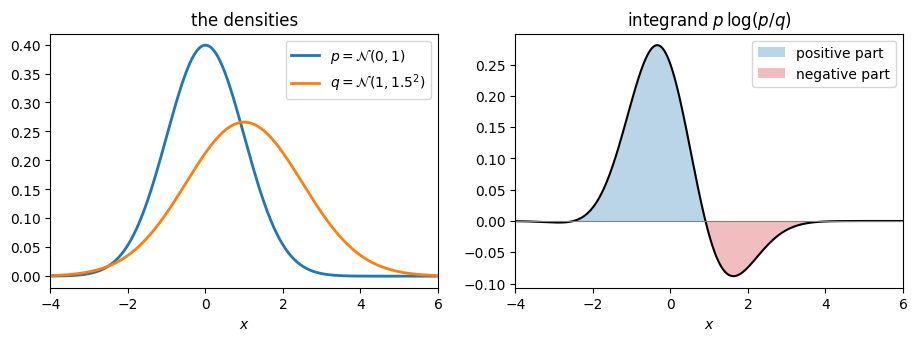

KL(p || q) = 0.3499   (closed form 0.3499)


In [2]:
logp, logq = log_normal(x, 0, 1), log_normal(x, 1, 1.5)
p, q = np.exp(logp), np.exp(logq)
f = p * (logp - logq)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.3))
ax0.plot(x, p, "C0", lw=2, label=r"$p=\mathcal{N}(0,1)$")
ax0.plot(x, q, "C1", lw=2, label=r"$q=\mathcal{N}(1,1.5^2)$")
ax0.set_xlim(-4, 6); ax0.set_xlabel("$x$"); ax0.set_title("the densities"); ax0.legend()
ax1.fill_between(x, f, where=f > 0, color="C0", alpha=0.3, lw=0, label="positive part")
ax1.fill_between(x, f, where=f < 0, color="C3", alpha=0.3, lw=0, label="negative part")
ax1.plot(x, f, "k", lw=1.5)
ax1.axhline(0, color="0.5", lw=0.8)
ax1.set_xlim(-4, 6); ax1.set_xlabel("$x$"); ax1.set_title(r"integrand $p\,\log(p/q)$"); ax1.legend()
plt.show()

print(f"KL(p || q) = {kl(logp, logq):.4f}   (closed form {kl_normal(0, 1, 1, 1.5):.4f})")

For two Gaussians the integral can be done by hand:

$$\mathrm{KL}\big(\mathcal{N}(\mu_1,\sigma_1^2)\,\|\,\mathcal{N}(\mu_2,\sigma_2^2)\big)
= \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac12 .$$

Check it on a few random pairs:

In [3]:
rng = np.random.default_rng(166)
print(f"{'mu1':>6} {'s1':>5} {'mu2':>6} {'s2':>5} {'numerical':>10} {'formula':>10}")
for _ in range(5):
    mu1, mu2 = rng.uniform(-3, 3, 2)
    s1, s2 = rng.uniform(0.5, 3, 2)
    print(f"{mu1:6.2f} {s1:5.2f} {mu2:6.2f} {s2:5.2f} "
          f"{kl(log_normal(x, mu1, s1), log_normal(x, mu2, s2)):10.4f} {kl_normal(mu1, s1, mu2, s2):10.4f}")

   mu1    s1    mu2    s2  numerical    formula
  1.30  2.26  -1.98  1.08     5.5940     5.5940
  2.65  1.59   1.04  0.87     2.2735     2.2735
 -0.98  1.34   2.62  2.90     1.1459     1.1459
 -0.18  2.85   1.21  0.55    14.7569    14.7569
 -2.95  2.32  -0.11  2.04     0.9873     0.9873


## 2. Two Gaussians shifted against each other

With equal variances the formula gives $\mathrm{KL}\big(\mathcal{N}(0,1)\,\|\,\mathcal{N}(\mu,1)\big) = \mu^2/2$.

largest error vs mu^2/2: 7.1e-15


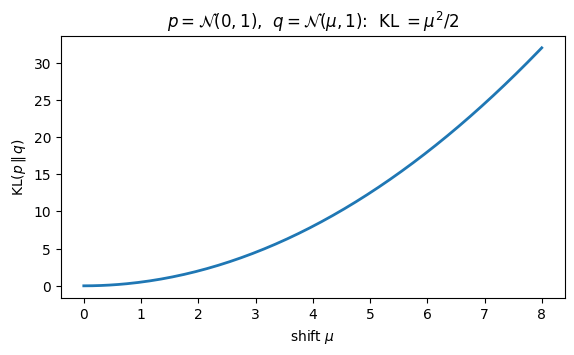

In [4]:
shifts = np.linspace(0, 8, 161)
KL = np.array([kl(log_normal(x, 0, 1), log_normal(x, mu, 1)) for mu in shifts])
print(f"largest error vs mu^2/2: {np.abs(KL - shifts**2 / 2).max():.1e}")

plt.figure(figsize=(6.5, 3.4))
plt.plot(shifts, KL, "C0", lw=2)
plt.xlabel(r"shift $\mu$"); plt.ylabel(r"$\mathrm{KL}(p\,\|\,q)$")
plt.title(r"$p=\mathcal{N}(0,1)$,  $q=\mathcal{N}(\mu,1)$:  KL $=\mu^2/2$")
plt.show()

The divergence **grows without bound**. Far out in the tails of $q$, the log-ratio $\log(p/q)$ is huge, and
$p$ still puts some mass there. Here, and only here because the variances are equal, the divergence is
also symmetric: swapping $p$ and $q$ gives the same $\mu^2/2$.

## 3. The order matters

Keep the mean fixed and change the spread: $p = \mathcal{N}(0,1)$ and $q = \mathcal{N}(0,\sigma^2)$. Then

$$\mathrm{KL}(p\,\|\,q) = \log\sigma + \frac{1}{2\sigma^2} - \frac12, \qquad
\mathrm{KL}(q\,\|\,p) = -\log\sigma + \frac{\sigma^2}{2} - \frac12 .$$

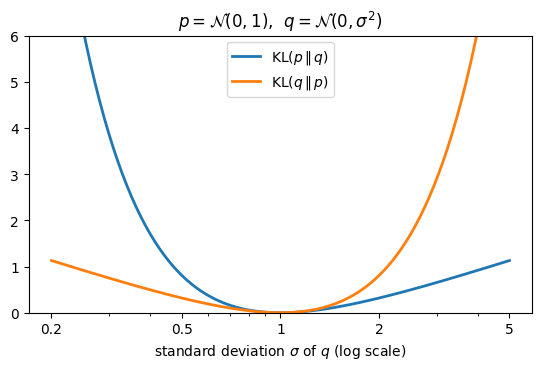

In [5]:
sigmas = np.geomspace(0.2, 5, 201)
logp = log_normal(x, 0, 1)
pq = np.array([kl(logp, log_normal(x, 0, s)) for s in sigmas])
qp = np.array([kl(log_normal(x, 0, s), logp) for s in sigmas])

plt.figure(figsize=(6.5, 3.6))
plt.plot(sigmas, pq, "C0", lw=2, label=r"$\mathrm{KL}(p\,\|\,q)$")
plt.plot(sigmas, qp, "C1", lw=2, label=r"$\mathrm{KL}(q\,\|\,p)$")
plt.xscale("log"); plt.ylim(0, 6)
plt.xticks([0.2, 0.5, 1, 2, 5], ["0.2", "0.5", "1", "2", "5"])
plt.xlabel(r"standard deviation $\sigma$ of $q$ (log scale)"); plt.legend(loc="upper center")
plt.title(r"$p=\mathcal{N}(0,1)$,  $q=\mathcal{N}(0,\sigma^2)$")
plt.show()

* $\mathrm{KL}(p\,\|\,q)$ averages over $p$. It is large when $q$ is **too narrow** ($\sigma < 1$): then $q$ is tiny in
  the tails of $p$, exactly where $p$ still has mass and $\log(p/q)$ is large.
* $\mathrm{KL}(q\,\|\,p)$ averages over $q$. It is large when $q$ is **too wide**: then $q$ puts mass where $p$ is tiny.

In words: $\mathrm{KL}(p\,\|\,q)$ is large when $q$ misses something $p$ does; $\mathrm{KL}(q\,\|\,p)$ is large when $q$
does something $p$ does not.

## 4. When the divergence is infinite

Let $p = \text{Uniform}(-1,1)$ and $q = \mathcal{N}(0,1)$. Then

$$\mathrm{KL}(p\,\|\,q) = -\log 2 + \tfrac12\log(2\pi) + \tfrac16 \approx 0.392, \qquad \mathrm{KL}(q\,\|\,p) = \infty,$$

because $q$ puts mass outside $[-1,1]$, where $p = 0$ and $\log(q/p) = \infty$. In general,
$\mathrm{KL}(p\,\|\,q)$ is finite only if $q > 0$ everywhere that $p > 0$.

In [6]:
inside = (x >= -1 - 1e-9) & (x < 1 - 1e-9)        # [-1, 1) on the grid, so the density integrates to exactly 1
with np.errstate(divide="ignore"):
    log_unif = np.where(inside, np.log(0.5), -np.inf)
log_gauss = log_normal(x, 0, 1)
print(f"KL(uniform || normal) = {kl(log_unif, log_gauss):.4f}   "
      f"(exact {-np.log(2) + 0.5 * np.log(2 * np.pi) + 1 / 6:.4f})")
print(f"KL(normal || uniform) = {kl(log_gauss, log_unif)}")

KL(uniform || normal) = 0.3925   (exact 0.3925)
KL(normal || uniform) = inf


## 5. Maximum likelihood minimizes a KL divergence

Draw $X_1,\dots,X_n$ from $p$ and fit a model $q_\theta$. The average log-likelihood is, by the law of large numbers,

$$\frac1n\sum_{i=1}^n \log q_\theta(X_i) \;\approx\; \mathbb{E}_p\big[\log q_\theta(X)\big]
= -\,\mathrm{KL}(p\,\|\,q_\theta) + \mathbb{E}_p\big[\log p(X)\big],$$

and the last term does not depend on $\theta$. So maximizing the likelihood is, for large $n$,
the same as minimizing $\mathrm{KL}(p\,\|\,q_\theta)$. Check it with data from $p = \mathcal{N}(2, 1.5^2)$
and the model $q_\theta = \mathcal{N}(\theta, 1)$, whose variance is deliberately wrong.

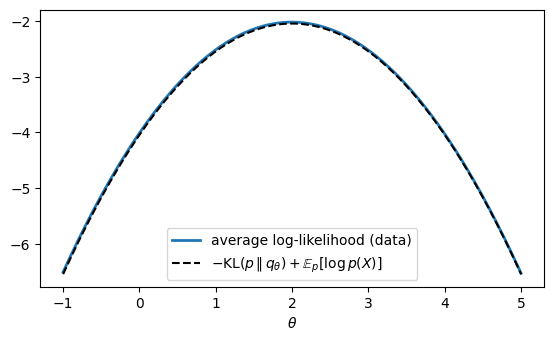

maximizer of the likelihood: theta = 2.00  (sample mean 1.996)
minimizer of KL(p || q_theta): theta = 2.00


In [7]:
n = 1000
data = rng.normal(2, 1.5, n)
thetas = np.linspace(-1, 5, 301)
avg_loglik = np.array([log_normal(data, th, 1).mean() for th in thetas])
neg_kl = -kl_normal(2, 1.5, thetas, 1)
entropy_term = -0.5 * np.log(2 * np.pi * 1.5**2) - 0.5          # E_p[log p(X)] for N(2, 1.5^2)

plt.figure(figsize=(6.5, 3.6))
plt.plot(thetas, avg_loglik, "C0", lw=2, label="average log-likelihood (data)")
plt.plot(thetas, neg_kl + entropy_term, "k--", lw=1.5, label=r"$-\mathrm{KL}(p\,\|\,q_\theta) + \mathbb{E}_p[\log p(X)]$")
plt.xlabel(r"$\theta$"); plt.legend(loc="lower center")
plt.show()

print(f"maximizer of the likelihood: theta = {thetas[avg_loglik.argmax()]:.2f}  (sample mean {data.mean():.3f})")
print(f"minimizer of KL(p || q_theta): theta = {thetas[neg_kl.argmax()]:.2f}")

The two curves lie almost on top of each other, and both peak near $\theta = 2$. Even though the model's
variance is wrong, maximum likelihood finds the member of the model that is closest to $p$ in the sense
of $\mathrm{KL}(p\,\|\,q_\theta)$, in this direction and not the other.

## Things to try

* In Section 1, swap $p$ and $q$. Where is the integrand negative now?
* In Section 3, which $\sigma > 1$ gives the same $\mathrm{KL}(p\,\|\,q)$ as $\sigma = 0.5$?
* In Section 4, replace the uniform by a Laplace density $\tfrac12 e^{-|x|}$. Which directions are finite?
* In Section 5, use $n = 20$ instead of $1000$. How close are the two curves?

The notebooks `lp.ipynb` and `wasserstein.ipynb` look at two other ways to compare distributions;
`probdistance.ipynb` compares all of them on the same examples.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. The Kullback–Leibler distance is equation (9.6) in Wasserman, *All of Statistics*, where it is used to prove that maximum likelihood estimators are consistent (Section 9.5).